# VEP Analysis

In [1]:
%load_ext autoreload
%autoreload 2

import os
# only load this one time per session
if 'NOTEBOOK_INITIALIZED' not in globals():
    os.chdir(os.path.dirname(os.path.abspath('.')))
    NOTEBOOK_INITIALIZED = True
    
import pandas as pd
import polars as pl
import seqpro as sp
import numpy as np
import pooch
import seaborn as sns
import matplotlib.pyplot as plt
from tqdm import tqdm
from pathlib import Path
from tempfile import TemporaryDirectory
import genvarloader as gvl

# Local code
import src.genvarloader as GVL
import src.vep_pipeline as vp
import src.vep_analysis as va
import src.utils as utils
import src.clinvar as cv

In [83]:
### Attempts to add new slots to the xarray dataset ###

# import xarray as xr

# xr_ds = xr.open_dataset(xr_ds_path, mode="a-")

# new_slots=  np.append(xr_ds.coords["slot"].data, "delta_pow2_mean")
# print(new_slots)
# xr_ds["flashzoi"].assign_coords({"slot": ("slot", new_slots)})

## Import non-null VEP results

In [2]:
variant_set="clinvar_utr_snv"
vep_df = vp.load_vep_results_mfdataset(xr_mfds_dir=os.path.join(
    os.path.expanduser('~'),
    "projects/data/1000_Genomes_on_GRCh38",
    variant_set
), 
    dropna_subset=["flashzoi"]
    )
vep_df.head()

/home/schilder/.conda/envs/flashzoi/lib/python3.12/site-packages/zarr/codecs/vlen_utf8.py:44: UserWarning: The codec `vlen-utf8` is currently not part in the Zarr format 3 specification. It may not be supported by other zarr implementations and may change in the future.
  return cls(**configuration_parsed)
/home/schilder/.conda/envs/flashzoi/lib/python3.12/site-packages/zarr/codecs/vlen_utf8.py:44: UserWarning: The codec `vlen-utf8` is currently not part in the Zarr format 3 specification. It may not be supported by other zarr implementations and may change in the future.
  return cls(**configuration_parsed)
/home/schilder/.conda/envs/flashzoi/lib/python3.12/site-packages/zarr/codecs/vlen_utf8.py:44: UserWarning: The codec `vlen-utf8` is currently not part in the Zarr format 3 specification. It may not be supported by other zarr implementations and may change in the future.
  return cls(**configuration_parsed)
/home/schilder/.conda/envs/flashzoi/lib/python3.12/site-packages/zarr/codecs

,site,sample,ploid,slot,evo2_40b_base,evo2_7b,flashzoi,spliceai,dnabert2,spliceai_mm,evo2_40b,evo2_7b_base
356860,chr21:25714732-25714733_T_C,REF,0,COVR,NaN,NaN,3.582652,NaN,NaN,NaN,NaN,NaN
356864,chr21:25714732-25714733_T_C,REF,0,delta_abs_mean,NaN,NaN,0.000995,NaN,NaN,NaN,NaN,NaN
356865,chr21:25714732-25714733_T_C,REF,0,delta_max_max,NaN,NaN,2.838457,NaN,NaN,NaN,NaN,NaN
356866,chr21:25714732-25714733_T_C,REF,0,delta_mean,NaN,NaN,0.000149,NaN,NaN,NaN,NaN,NaN
356867,chr21:25714732-25714733_T_C,REF,0,delta_pow2_mean,NaN,NaN,0.000056,NaN,NaN,NaN,NaN,NaN


## Estimate total time

Based on the existing results, estimate how long it will take to run all selected ClinVar variants. 

In [23]:
bed_utr = cv.read_bed("data/UTR/clinvar_utr_snv.bed.gz", simplify=True) 
va.estimate_runtime(vep_df,
                     total_sites=bed_utr["name"].n_unique(),
                     model_name="flashzoi",
                     time_col="time_total",
                     n_gpus=1)

Extracting ID columns.
Adding ID counts.
Using default maps.
Simplifying annotations.
7.08 minutes per site
Number of days it should take to run all 13771 sites genome-wide:
67.73


Get summary statistics for the VEP slots.

In [4]:
vep_df.groupby("slot")["flashzoi"].describe()

,count,mean,std,min,25%,50%,75%,max
slot,,,,,,,,
COVR,2008612.0,1.163548,1.231365,0.000000,0.548469,0.768324,1.231794,10.397758
delta_abs_mean,2008612.0,0.000891,0.001040,0.000000,0.000321,0.000589,0.001095,0.009684
delta_max_max,2008612.0,1.918426,4.258338,0.000000,0.357378,0.726096,1.687832,43.019333
delta_mean,2008612.0,-0.000063,0.000597,-0.006305,-0.000182,-0.000020,0.000084,0.004113
delta_pow2_mean,2008612.0,0.000201,0.000896,0.000000,0.000005,0.000014,0.000096,0.011400
len_seq_mut,2008612.0,524288.000000,0.000000,524288.000000,524288.000000,524288.000000,524288.000000,524288.000000
len_seq_wt,2008612.0,524288.000000,0.000000,524288.000000,524288.000000,524288.000000,524288.000000,524288.000000
output_length,2008612.0,524288.000000,0.000000,524288.000000,524288.000000,524288.000000,524288.000000,524288.000000
time_run_vep,2008612.0,0.106969,0.032201,0.059996,0.064514,0.130200,0.132269,0.172091


Plot a sampling of the various slot values, including different VEP metrics and metadata about how long each iteration took to run.

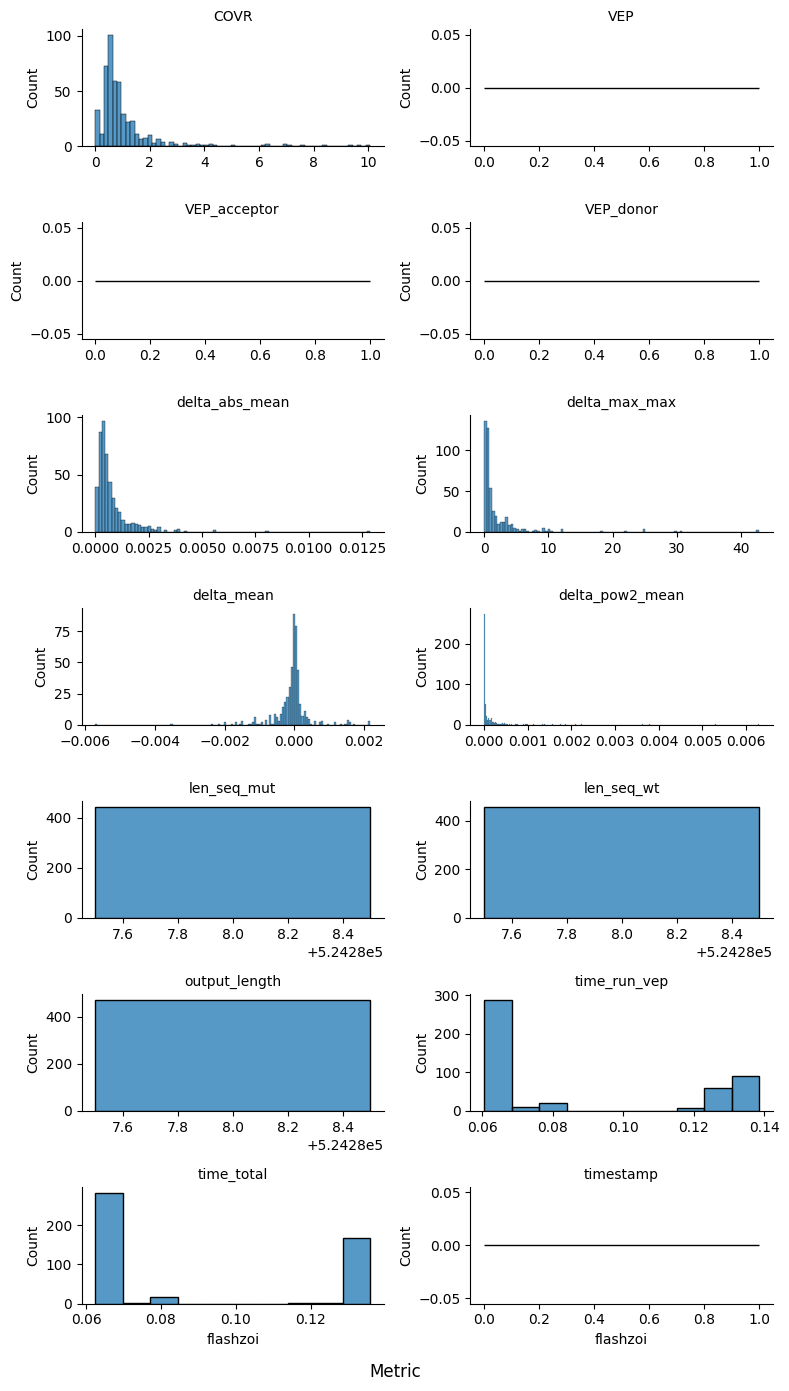

In [ ]:
va.summary_histograms(vep_df, x="flashzoi")


## Annotate VEP results with variant metadata

### Parse Disease IDs

Extracting ID columns.
Adding ID counts.
Using default maps.
Simplifying annotations.


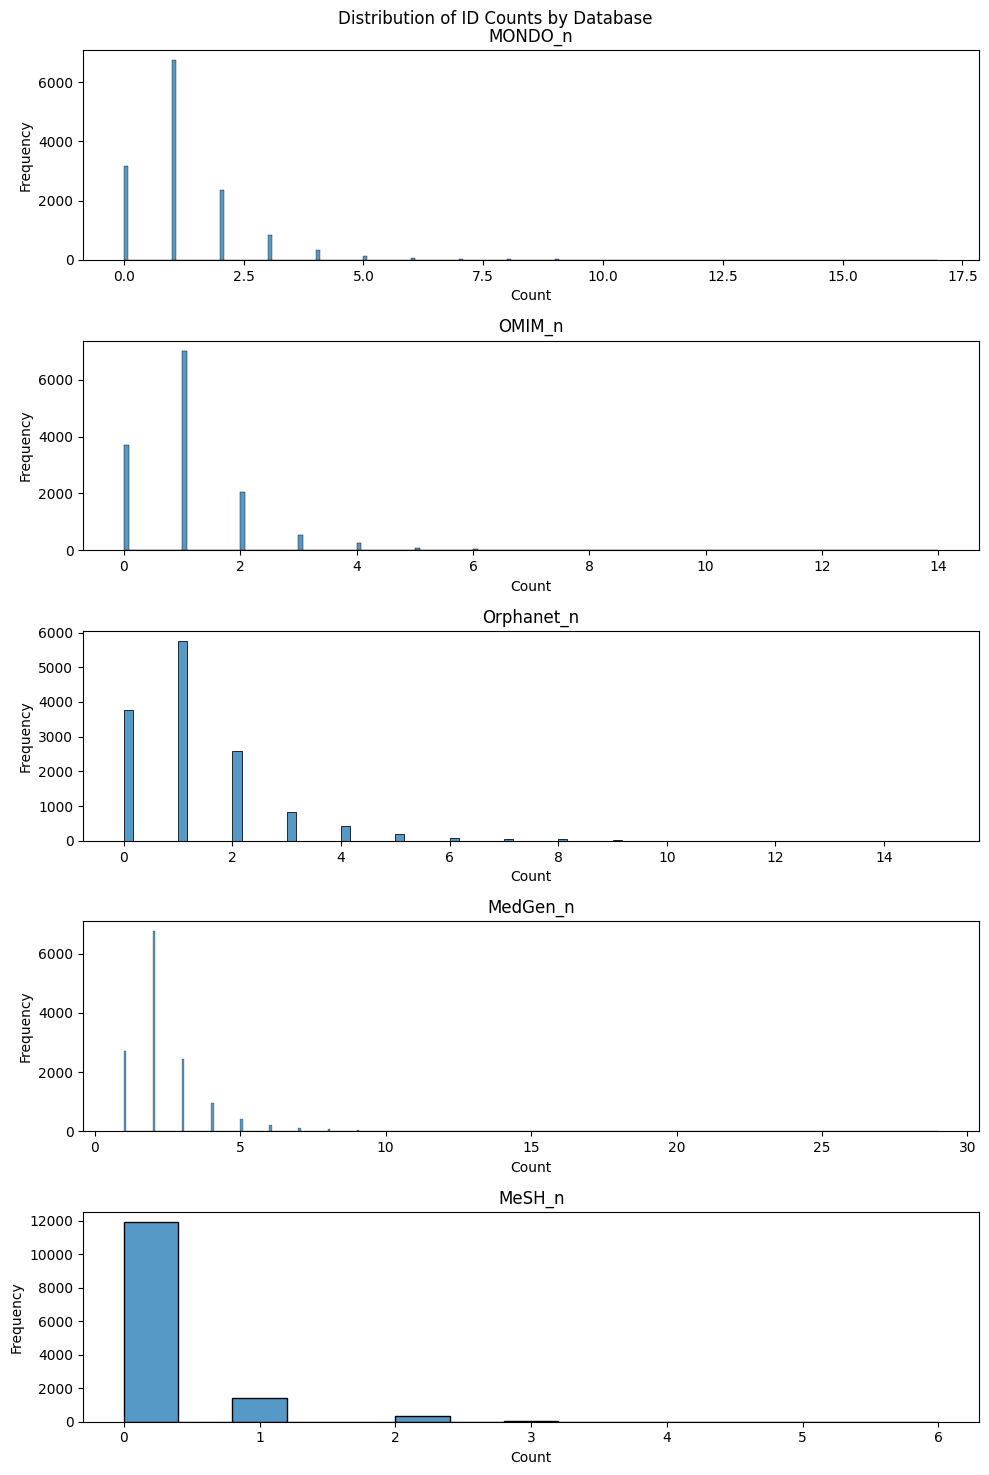

chrom,chromStart,chromEnd,name,score,REF,ALT,MC_id,MC_term,AF_ESP,AF_EXAC,AF_TGP,ALLELEID,CLNDISDB,CLNDN,CLNHGVS,CLNREVSTAT,CLNSIG,CLNVC,CLNVCSO,CLNSIGCONF,GENEINFO,MC,ORIGIN,RS,ONC,ONCDN,ONCDISDB,ONCREVSTAT,ONCCONF,SCI,SCIDN,SCIDISDB,SCIREVSTAT,CLNREVSTAT_score,MONDO,OMIM,Orphanet,MedGen,MeSH,MONDO_n,OMIM_n,Orphanet_n,MedGen_n,MeSH_n,CLNSIG_simple,CLNSIG_super_simple,GENE
str,i64,i64,str,f64,str,str,str,str,f64,f64,f64,i64,str,str,str,str,str,str,str,str,str,str,i64,i64,str,str,str,str,str,str,str,str,str,i64,list[str],list[str],list[str],list[str],list[str],u32,u32,u32,u32,u32,str,str,str
"""1""",1013541,1013542,"""chr1:1013541-1013542_T_C""",2.0,"""T""","""C""","""SO:0001623""","""5_prime_UTR_variant""",0.88579,null,0.90315,1175251,"""MedGen:C3661900|MONDO:MONDO:00…","""not_provided|Mendelian_suscept…","""NC_000001.11:g.1013541T>C""","""criteria_provided,_multiple_su…","""Benign""","""single_nucleotide_variant""","""SO:0001483""",null,"""ISG15:9636""","""SO:0001623|5_prime_UTR_variant""",1,15842,null,null,null,null,null,null,null,null,null,2,"[""MONDO:MONDO:0014502""]","[""OMIM:616126""]","[""Orphanet:319563""]","[""MedGen:C3661900"", ""MedGen:C4015293"", ""MedGen:CN169374""]",[],1,1,1,3,0,"""benign""","""benign""","""ISG15"""
"""1""",1055000,1055001,"""chr1:1055000-1055001_C_T""",2.0,"""C""","""T""","""SO:0001624""","""3_prime_UTR_variant""",0.34176,0.33342,0.34345,249353,"""MedGen:CN169374|MONDO:MONDO:00…","""not_specified|Congenital_myast…","""NC_000001.11:g.1055000C>T""","""criteria_provided,_multiple_su…","""Benign""","""single_nucleotide_variant""","""SO:0001483""",null,"""AGRN:375790""","""SO:0001624|3_prime_UTR_variant""",1,3121561,null,null,null,null,null,null,null,null,null,2,"[""MONDO:MONDO:0014052""]","[""OMIM:615120""]","[""Orphanet:590""]","[""MedGen:CN169374"", ""MedGen:C3808739"", ""MedGen:C3661900""]",[],1,1,1,3,0,"""benign""","""benign""","""AGRN"""
"""1""",1055037,1055038,"""chr1:1055037-1055038_T_C""",2.0,"""T""","""C""","""SO:0001624""","""3_prime_UTR_variant""",null,null,0.38399,1282674,"""MedGen:C3661900""","""not_provided""","""NC_000001.11:g.1055037T>C""","""criteria_provided,_multiple_su…","""Benign""","""single_nucleotide_variant""","""SO:0001483""",null,"""AGRN:375790""","""SO:0001624|3_prime_UTR_variant""",1,2465136,null,null,null,null,null,null,null,null,null,2,[],[],[],"[""MedGen:C3661900""]",[],0,0,0,1,0,"""benign""","""benign""","""AGRN"""
"""1""",1055137,1055138,"""chr1:1055137-1055138_C_T""",2.0,"""C""","""T""","""SO:0001624""","""3_prime_UTR_variant""",null,null,0.91793,1175253,"""MONDO:MONDO:0014052,MedGen:C38…","""Congenital_myasthenic_syndrome…","""NC_000001.11:g.1055137C>T""","""criteria_provided,_multiple_su…","""Benign""","""single_nucleotide_variant""","""SO:0001483""",null,"""AGRN:375790""","""SO:0001624|3_prime_UTR_variant""",1,2710872,null,null,null,null,null,null,null,null,null,2,"[""MONDO:MONDO:0014052""]","[""OMIM:615120""]","[""Orphanet:590""]","[""MedGen:C3808739"", ""MedGen:C3661900""]",[],1,1,1,2,0,"""benign""","""benign""","""AGRN"""
"""1""",1055153,1055154,"""chr1:1055153-1055154_G_A""",2.0,"""G""","""A""","""SO:0001624""","""3_prime_UTR_variant""",null,null,0.12181,1282812,"""MedGen:C3661900""","""not_provided""","""NC_000001.11:g.1055153G>A""","""criteria_provided,_multiple_su…","""Benign""","""single_nucleotide_variant""","""SO:0001483""",null,"""AGRN:375790""","""SO:0001624|3_prime_UTR_variant""",1,4308920,null,null,null,null,null,null,null,null,null,2,[],[],[],"[""MedGen:C3661900""]",[],0,0,0,1,0,"""benign""","""benign""","""AGRN"""


In [25]:
bed_utr = cv.read_bed("data/UTR/clinvar_utr_snv.bed.gz", 
                      extract_ids=True,
                      simplify=True) 

# Create histograms for each ID count column
id_cols = ['MONDO_n', 'OMIM_n', 'Orphanet_n', 'MedGen_n', 'MeSH_n']
fig, axes = plt.subplots(len(id_cols), 1, figsize=(10, 15))
fig.suptitle('Distribution of ID Counts by Database')

for idx, col in enumerate(id_cols):
    sns.histplot(data=bed_utr.to_pandas(), x=col, ax=axes[idx])
    axes[idx].set_title(f'{col}')
    axes[idx].set_xlabel('Count')
    axes[idx].set_ylabel('Frequency')

plt.tight_layout()
plt.show()

bed_utr.head()


In [24]:
# import src.owlready2 as OWL

# onto = OWL.get_onto_mondo()

# # Get counts of the most common pairwise MRCAs from a list of MONDO IDs
# mondo_ids = bed_utr.explode("MONDO").drop_nulls("MONDO")["MONDO"].str.replace("MONDO:MONDO:","MONDO:").to_list()[:10]
# sorted_mrcas = OWL.get_mrca_counts(onto, ids=mondo_ids)
# print(sorted_mrcas)

# anc = OWL.get_ancestors(onto,
#                  id=["MONDO:0005148",'MONDO:0100545'], 
#                  prefix="MONDO", 
#                  return_ids=True,
#                  lvl=1)
# anc

In [3]:
bed_utr = cv.read_bed("data/UTR/clinvar_utr_snv.bed.gz", simplify=True) 

print("bed shape:",bed_utr.shape)
print("vep_df shape:",vep_df.shape)

print(bed_utr["ONC"].value_counts().sort(by="count", descending=True))
print(bed_utr["CLNSIG"].value_counts().sort(by="count", descending=True))
print(bed_utr["CLNSIGCONF"].value_counts().sort(by="count", descending=True))
print(bed_utr["CLNSIG_simple"].value_counts().sort(by="count", descending=True))
print(bed_utr["CLNSIG_super_simple"].value_counts().sort(by="count", descending=True))

Extracting ID columns.
Adding ID counts.
Using default maps.
Simplifying annotations.
bed shape: (13771, 48)
vep_df shape: (42415360, 12)
shape: (4, 2)
┌────────────────────────┬───────┐
│ ONC                    ┆ count │
│ ---                    ┆ ---   │
│ str                    ┆ u32   │
╞════════════════════════╪═══════╡
│ null                   ┆ 13735 │
│ Oncogenic              ┆ 20    │
│ Likely_oncogenic       ┆ 15    │
│ Uncertain_significance ┆ 1     │
└────────────────────────┴───────┘
shape: (9, 2)
┌─────────────────────────────────┬───────┐
│ CLNSIG                          ┆ count │
│ ---                             ┆ ---   │
│ str                             ┆ u32   │
╞═════════════════════════════════╪═══════╡
│ Benign                          ┆ 8029  │
│ Likely_benign                   ┆ 1851  │
│ Benign/Likely_benign            ┆ 1836  │
│ Pathogenic/Likely_pathogenic    ┆ 917   │
│ Pathogenic                      ┆ 846   │
│ Likely_pathogenic               ┆ 288   │


In [4]:
# Filter rows and merge variant metadata from BED file
delta_df = vep_df.loc[(vep_df["slot"].str.startswith("delta_") | vep_df["slot"].str.startswith("COVR"))].copy().merge(
    bed_utr.to_pandas(), 
                       left_on="site", 
                       right_on="name")

print("Merged vep_df/bed shape:",delta_df.shape)
print("\n",delta_df["ONC"].value_counts().sort_values(ascending=False))
print("\n",delta_df["CLNSIG"].value_counts().sort_values(ascending=False))
print("\n",delta_df["CLNSIGCONF"].value_counts().sort_values(ascending=False))
print("\n",delta_df["CLNSIG_simple"].value_counts().sort_values(ascending=False))
print("\n",delta_df["CLNSIG_super_simple"].value_counts().sort_values(ascending=False))

Merged vep_df/bed shape: (21207680, 60)

 Series([], Name: count, dtype: int64)

 CLNSIG
Benign                          11419520
Likely_benign                    2574490
Pathogenic                       2574490
Benign/Likely_benign             2243120
Pathogenic/Likely_pathogenic     1937240
Likely_pathogenic                 433330
Benign|other                       25490
Name: count, dtype: int64

 Series([], Name: count, dtype: int64)

 CLNSIG_simple
benign           11445010
likely_benign     4817610
path              2574490
likely_path       2370570
Name: count, dtype: int64

 CLNSIG_super_simple
benign    16262620
path       4945060
Name: count, dtype: int64


Preprocess VEP data and add normalized column. 

In [10]:
from sklearn.preprocessing import MinMaxScaler, RobustScaler, Normalizer
# scaler = MinMaxScaler()
scaler = RobustScaler()
# scaler = Normalizer()

# Group by site and slot, then apply minmax scaling
delta_df.loc[:,"flashzoi_norm"] = delta_df.groupby(["GENE","slot"])["flashzoi"].transform(
    lambda x: scaler.fit_transform(x.values.reshape(-1, 1)).ravel() if len(x) > 0 else 0
)

 # Sort by scoring strategy
clinsig_col="CLNSIG_simple"
delta_df = utils.sort_by_reverse_string(delta_df, 
                                        column='slot',
                                        extra_sort_cols=[clinsig_col],
                                        ascending=[True, False])

Violin plot

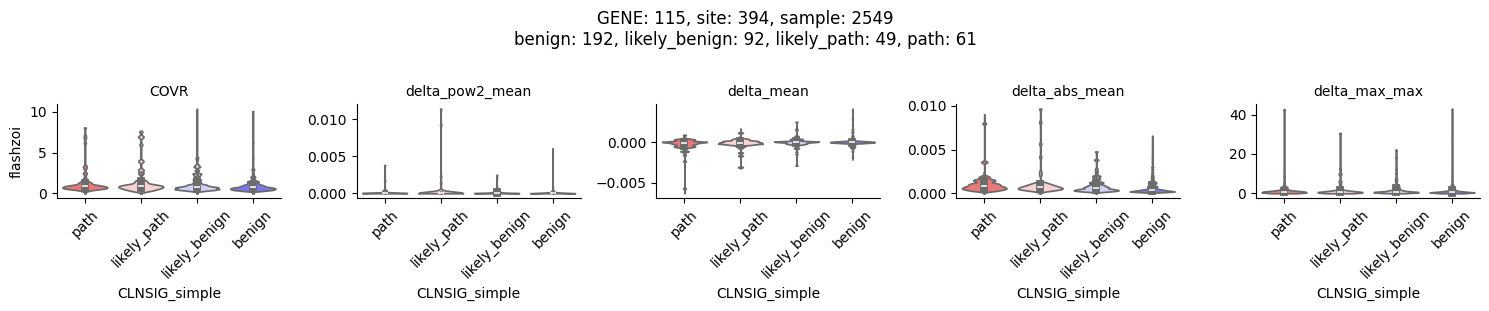

In [8]:
va.plot_violin(delta_df, hue="CLNSIG_simple")

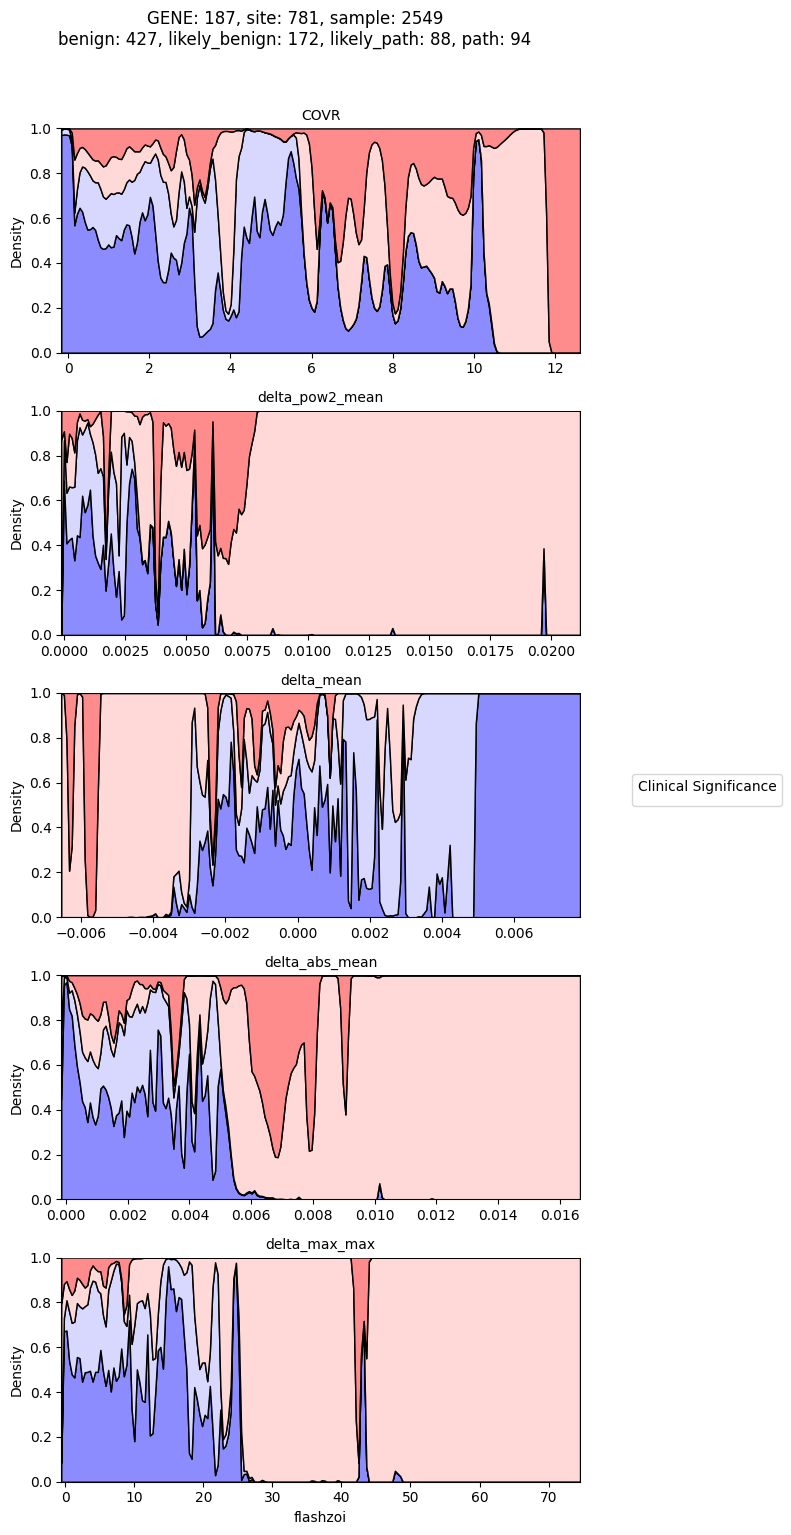

In [12]:
va.plot_kde(delta_df, 
         x="flashzoi", 
         multiple="fill"
         )

### Grouped by Disease annotation

In [ ]:
delta_df["MONDO"]

In [12]:
delta_df.loc[delta_df["MONDO_n"]>0]["MONDO"]

50980                            [MONDO:MONDO:0004975]
50981                            [MONDO:MONDO:0004975]
50982                            [MONDO:MONDO:0004975]
50983                            [MONDO:MONDO:0004975]
50984                            [MONDO:MONDO:0004975]
                               ...                    
21105715    [MONDO:MONDO:0010557, MONDO:MONDO:0019118]
21105716    [MONDO:MONDO:0010557, MONDO:MONDO:0019118]
21105717    [MONDO:MONDO:0010557, MONDO:MONDO:0019118]
21105718    [MONDO:MONDO:0010557, MONDO:MONDO:0019118]
21105719    [MONDO:MONDO:0010557, MONDO:MONDO:0019118]
Name: MONDO, Length: 15523410, dtype: object

In [ ]:
delta_df.loc[:,"rsID"] = "rs" + delta_df["RS"].fillna(0).round().astype(int).astype(str)

within_site_var, within_site_var_mean = va.get_mondo_within_site_var(delta_df.loc[delta_df["slot"]=="COVR"],
                                                                      vep_col = "flashzoi" )
within_site_var.head()

Extracting 1 ID column(s).
Extracting MONDO IDs.


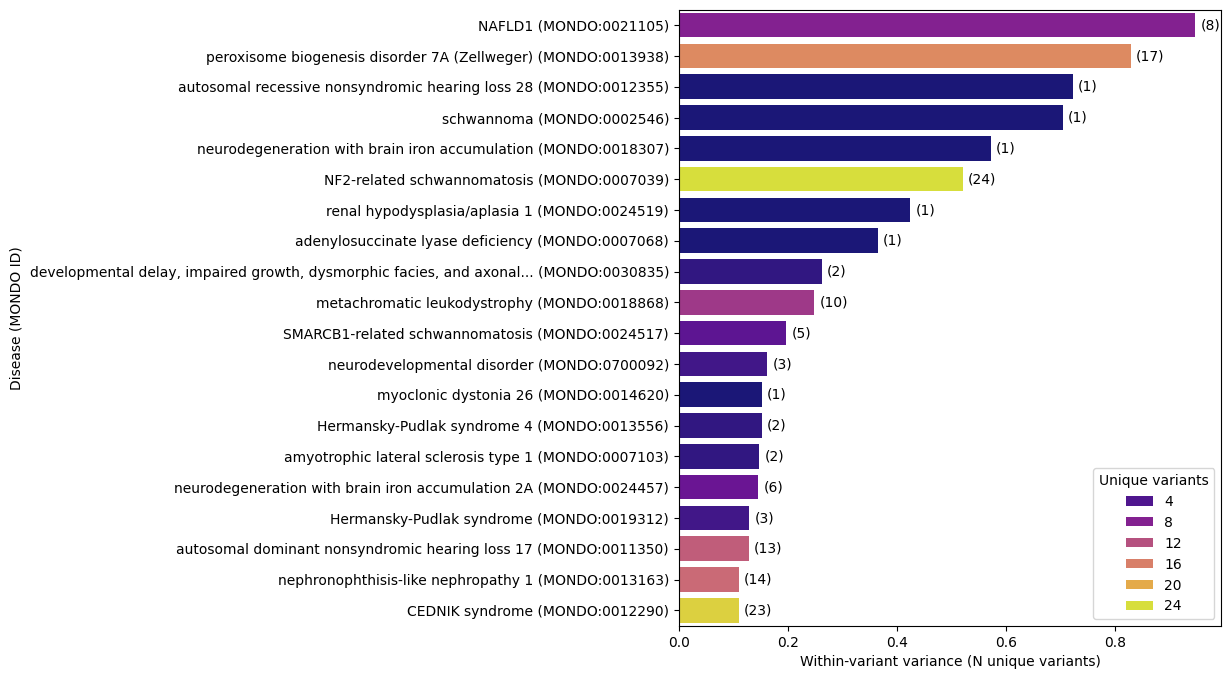

In [17]:
va.plot_top_mondo(within_site_var_mean=within_site_var_mean)

## Forrest2020 variant penetrance data

### Merge at variant level

In [21]:
#### Preprocessing to make the data more compact and shareable via GitHub  
# biome = pd.read_excel("data/penetrance/Forrest2020/Forrest_Penetrance_PenetranceDataset.xlsx", 
#                       sheet_name="BioMe")
# ukb = pd.read_excel("data/penetrance/Forrest2020/Forrest_Penetrance_PenetranceDataset.xlsx", 
#                       sheet_name="UKB")
# biome.to_csv("data/penetrance/Forrest2020/biome.csv.gz", index=False)
# ukb.to_csv("data/penetrance/Forrest2020/ukb.csv.gz", index=False)

### Reimport data
biome = pd.read_csv("data/penetrance/Forrest2020/biome.csv.gz")
ukb = pd.read_csv("data/penetrance/Forrest2020/ukb.csv.gz")

biome.head()
ukb.head()


,Variant,CHR,POS,REF,ALT,rsID,ClinVar_Summary,Consequence,RefSeq_Gene,ClinVar_Classification,...,60yo_ASA_Penetrance,40yo_AFR_Affected_Carriers,40yo_AFR_Total_Carriers,40yo_AFR_Penetrance,50yo_AFR_Affected_Carriers,50yo_AFR_Total_Carriers,50yo_AFR_Penetrance,60yo_AFR_Affected_Carriers,60yo_AFR_Total_Carriers,60yo_AFR_Penetrance
0,4.1799344.G.A_A,4,1799344,G,A,rs369232922,NM_000142.4(FGFR3):c.200G>A (p.Gly67Asp),missense_variant,FGFR3,Uncertain_significance,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,4.1804404.T.C_C,4,1804404,T,C,rs17881656,NM_000142.4(FGFR3):c.1150T>C (p.Phe384Leu),missense_variant,FGFR3,Benign/Likely_benign,...,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0
2,4.1804902.C.T_T,4,1804902,C,T,rs61735104,NM_000142.4(FGFR3):c.1345C>T (p.Pro449Ser),missense_variant,FGFR3,Benign/Likely_benign,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,4.1805636.A.G_G,4,1805636,A,G,rs80053154,NM_000142.4(FGFR3):c.1612A>G (p.Ile538Val),missense_variant,FGFR3,Pathogenic,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,4.1805643.A.G_G,4,1805643,A,G,rs77722678,NM_000142.4(FGFR3):c.1619A>G (p.Asn540Ser),missense_variant,FGFR3,Uncertain_significance,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [24]:
biome["HGVS"] = "g." + biome["POS"].astype(str) + biome["REF"] + ">" + biome["ALT"]
ukb["HGVS"] = "g." + ukb["POS"].astype(str) + ukb["REF"] + ">" + ukb["ALT"]

In [25]:
utils.intersect(delta_df["HGVS"].unique().tolist(),
                biome["HGVS"].tolist())

KeyError: 'HGVS'

In [159]:
utils.intersect(delta_df["rsID"].unique().tolist(),
                ukb["rsID"].tolist())

['rs28909982',
 'rs151315725',
 'rs17883862',
 'rs145707160',
 'rs536907995',
 'rs587781269',
 'rs587777241',
 'rs587782070',
 'rs761494650',
 'rs730881701',
 'rs137853007',
 'rs146350208']

In [138]:
within_site_var["rsID"] = "rs" + within_site_var["RS"].fillna(0).round().astype(int).astype(str)
within_site_var["rsID"]

594        rs361703
92        rs5763431
758       rs1810508
87      rs112175950
595     rs112015789
           ...     
372     rs137852573
373     rs137852573
374     rs137852573
282    rs1269514277
396     rs267608470
Name: rsID, Length: 808, dtype: object

In [177]:
ukb.value_counts("Consequence")

Consequence
missense_variant                        35069
synonymous_variant                      17250
stop_gained                              2493
frameshift_variant                       1148
splice_donor_variant                      863
splice_acceptor_variant                   632
start_lost                                189
stop_lost                                  89
synonymous_variant, missense_variant        7
missense_variant, synonymous_variant        3
Name: count, dtype: int64

In [175]:
rmerge = within_site_var.merge(ukb,
                                    on="rsID",
                                    how="inner")
rmerge.head()

,MONDO,MONDO_split,CLNSIG_simple,GENE,CLNHGVS,RS,site,slot,flashzoi,haplotype,...,40yo_AFR_Affected_Carriers,40yo_AFR_Total_Carriers,40yo_AFR_Penetrance,50yo_AFR_Affected_Carriers,50yo_AFR_Total_Carriers,50yo_AFR_Penetrance,60yo_AFR_Affected_Carriers,60yo_AFR_Total_Carriers,60yo_AFR_Penetrance,HGVS
0,MONDO:0002629|MONDO:0700275|MONDO:0700271|MOND...,MONDO:0016419,likely_path,CHEK2,NC_000022.11:g.28725338T>C,28909982.0,chr22:28725338-28725339_T_C,COVR,0.035807,5098,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,g.28725338T>C
1,MONDO:0002629|MONDO:0700275|MONDO:0700271|MOND...,MONDO:0016419,likely_path,CHEK2,NC_000022.11:g.28725338T>C,28909982.0,chr22:28725338-28725339_T_C,COVR,0.035807,5098,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,g.28725338T>C
2,MONDO:0002629|MONDO:0700275|MONDO:0700271|MOND...,MONDO:0700271,likely_path,CHEK2,NC_000022.11:g.28725338T>C,28909982.0,chr22:28725338-28725339_T_C,COVR,0.035807,5098,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,g.28725338T>C
3,MONDO:0002629|MONDO:0700275|MONDO:0700271|MOND...,MONDO:0700271,likely_path,CHEK2,NC_000022.11:g.28725338T>C,28909982.0,chr22:28725338-28725339_T_C,COVR,0.035807,5098,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,g.28725338T>C
4,MONDO:0002629|MONDO:0700275|MONDO:0700271|MOND...,MONDO:0007254,likely_path,CHEK2,NC_000022.11:g.28725338T>C,28909982.0,chr22:28725338-28725339_T_C,COVR,0.035807,5098,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,g.28725338T>C


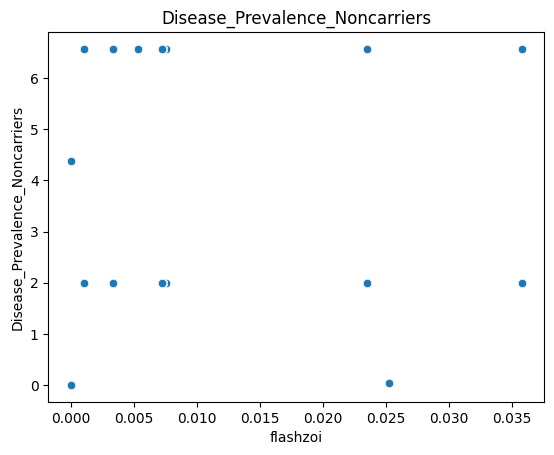

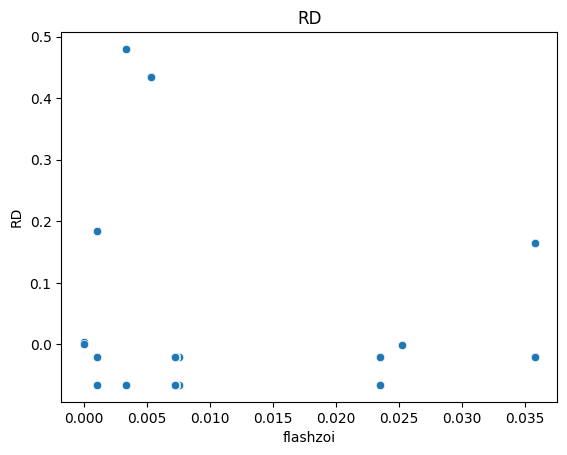

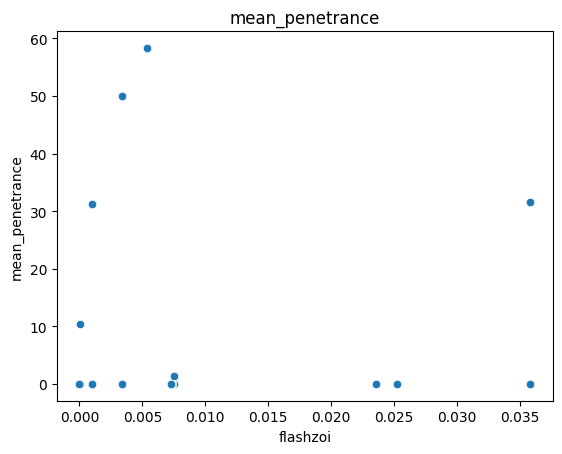

In [176]:
penetrance_cols = [x for x in rmerge.columns if "penetrance" in x.lower()]
rmerge["mean_penetrance"] = rmerge[penetrance_cols].mean(axis=1)

for col in ['Disease_Prevalence_Noncarriers','RD','mean_penetrance']:
    plt.figure()
    sns.scatterplot(data=rmerge,
                   x="flashzoi",
                   y=col) 
    plt.title(col)

### Merge at disease level

In [165]:
utils.intersect(within_site_var_mean["MONDO_label"].str.lower().tolist(),
                biome["Disease"].str.lower().tolist())

['li-fraumeni syndrome',
 'cardiomyopathy',
 'frontotemporal dementia',
 'schizophrenia',
 'retinitis pigmentosa']

In [166]:
biome["disease_xref"] = biome["Disease"].str.lower()
within_site_var_mean["disease_xref"] = within_site_var_mean["MONDO_label"].str.lower()

dmerge= within_site_var_mean.merge(biome,
                           on="disease_xref",
                           how="inner")
dmerge.head()

,MONDO_split,MONDO_label,flashzoi,site,haplotype,disease_xref,Variant,CHR,POS,REF,...,50yo_HIS_Affected_Carriers,50yo_HIS_Total_Carriers,50yo_HIS_Penetrance,60yo_HIS_Affected_Carriers,60yo_HIS_Total_Carriers,60yo_HIS_Penetrance,70yo_HIS_Affected_Carriers,70yo_HIS_Total_Carriers,70yo_HIS_Penetrance,HGVS
0,MONDO:0017276,frontotemporal dementia,0.004585,1,5098,frontotemporal dementia,17.45962399.G.T_T,17,45962399,G,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,g.45962399G>T
1,MONDO:0017276,frontotemporal dementia,0.004585,1,5098,frontotemporal dementia,17.45974435.G.A_A,17,45974435,G,...,1.0,1.0,100.0,1.0,1.0,100.0,1.0,1.0,100.0,g.45974435G>A
2,MONDO:0017276,frontotemporal dementia,0.004585,1,5098,frontotemporal dementia,17.45974436.C.T_T,17,45974436,C,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,g.45974436C>T
3,MONDO:0017276,frontotemporal dementia,0.004585,1,5098,frontotemporal dementia,17.45974448.C.T_T,17,45974448,C,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,g.45974448C>T
4,MONDO:0017276,frontotemporal dementia,0.004585,1,5098,frontotemporal dementia,17.45978387.G.T_T,17,45978387,G,...,0.0,5.0,0.0,0.0,4.0,0.0,0.0,1.0,0.0,g.45978387G>T


<Axes: xlabel='flashzoi', ylabel='RD'>

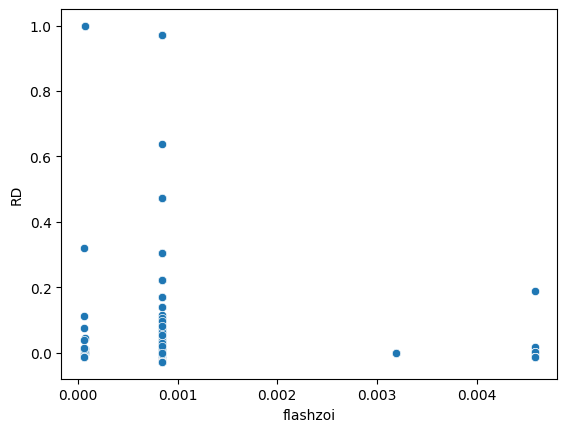

In [170]:
plt.figure()
sns.scatterplot(data=dmerge,
               x="flashzoi",
               y="RD") 

In [35]:
delta_df.groupby("slot")["flashzoi"].describe()

,count,mean,std,min,25%,50%,75%,max
slot,,,,,,,,
COVR,3956048.0,1.029006,1.161068,0.000000,0.498185,0.717498,1.097856,12.442434
delta_abs_mean,3956048.0,0.000847,0.001049,0.000000,0.000300,0.000528,0.001028,0.016506
delta_max_max,3956048.0,1.870110,3.899843,0.000000,0.362518,0.751173,1.742798,73.991501
delta_mean,3956048.0,-0.000062,0.000561,-0.006466,-0.000136,-0.000009,0.000066,0.007744
delta_pow2_mean,3956048.0,0.000198,0.000868,0.000000,0.000004,0.000015,0.000083,0.021061


/home/schilder/projects/VEP_DNA/src/vep_analysis.py:471: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  y=1.03, x=0.125, ha='left')


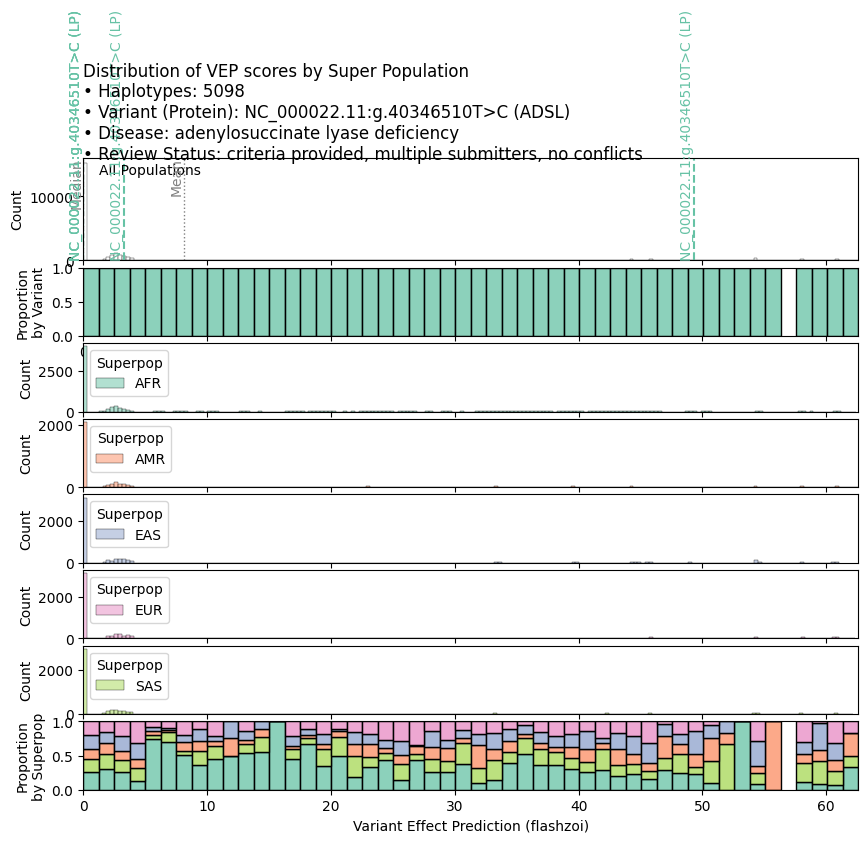

In [44]:
plot_dat = va.plot_vep_by_superpop(delta_df,
                        within_site_var,
                        i=0,
                        vep_col = "flashzoi",
                        variant_col = "CLNHGVS",
                        clinsig_col = "CLNSIG_simple",
                        hue_top = "CLNHGVS",
                        hue = "Super Population",
                        hue_bottom = "Super Population",
                        )

In [156]:
 # Get unique super populations excluding REF
super_pops = [pop for pop in plot_df["Super Population"].unique() if pop != "REF"]

# Calculate histograms for each population
dict_d = {}
dict_p = {}

# Compare each population to overall distribution
overall_dist = plot_df.loc[:, model_name].values
for pop in super_pops:
    pop_dist = plot_df.loc[plot_df["Super Population"]==pop, model_name].values
    p1, d_obs1, null_dist1 = utils.wasserstein_distance_permuted(pop_dist, overall_dist)
    dict_d[f"{pop}_vs_overall"] = d_obs1
    dict_p[f"{pop}_vs_overall"] = p1
    p2, d_obs2, null_dist2 = utils.wasserstein_distance_permuted(overall_dist, pop_dist)
    dict_d[f"overall_vs_{pop}"] = d_obs2
    dict_p[f"overall_vs_{pop}"] = p2

# Compare populations to each other
for i, pop1 in enumerate(super_pops):
    for pop2 in super_pops[i+1:]:
        hist1 = plot_df.loc[plot_df["Super Population"]==pop1, model_name].values
        hist2 = plot_df.loc[plot_df["Super Population"]==pop2, model_name].values
        p1, d_obs1, null_dist1 = utils.wasserstein_distance_permuted(hist1, hist2)
        p2, d_obs2, null_dist2 = utils.wasserstein_distance_permuted(hist2, hist1)
        
        # Store assymmetric distance
        dict_d[f"{pop1}_vs_{pop2}"] = d_obs1
        dict_d[f"{pop2}_vs_{pop1}"] = d_obs2
        dict_p[f"{pop1}_vs_{pop2}"] = p1
        dict_p[f"{pop2}_vs_{pop1}"] = p2

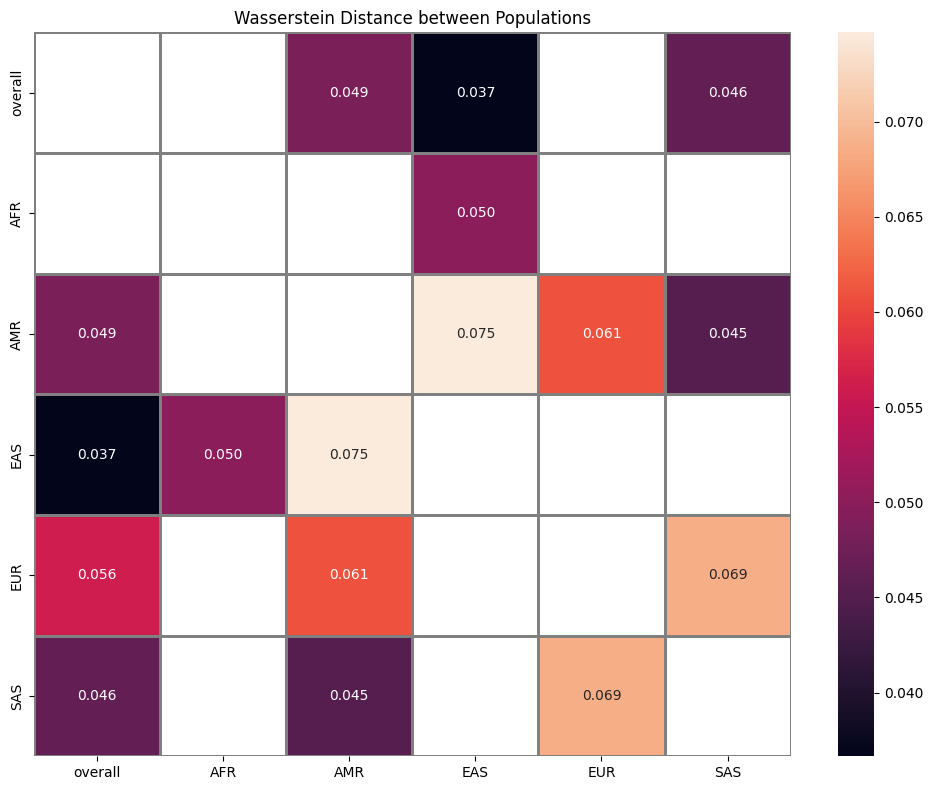

In [157]:

def dict_to_matrix(d):
    super_pops =[ "overall" ]+ sorted(set([pop for key in d.keys() if "_vs_" in key for pop in key.split("_vs_") if pop != "overall"]))

    X = np.zeros((len(super_pops), len(super_pops)))
    for key in d:
        if "_vs_" in key:
            pop1, pop2 = key.split("_vs_")
            i = super_pops.index(pop1)
            j = super_pops.index(pop2)
            if i != j:
                X[i,j] = d[key]
    # Add overall vs pop
    return X, super_pops
X_d, super_pops = dict_to_matrix(dict_d)
X_p, super_pops = dict_to_matrix(dict_p)

# Create a mask for the lower triangle
# mask = np.triu(np.ones_like(X_d, dtype=bool), k=1)  # k=1 excludes diagonal

# Plot heatmap of distances
plt.figure(figsize=(10, 8))
sns.heatmap(X_d, 
            xticklabels=super_pops,
            yticklabels=super_pops,
            annot=True,
            fmt='.3f',
            cmap='rocket',
            # If passed, data will not be shown in cells where mask is True. 
            # Cells with missing values are automatically masked.
            mask=(X_p<0.05),
            linewidths=1,  # Add grid lines
            linecolor='grey'  # Make grid lines white
            ) 
plt.title("Wasserstein Distance between Populations")
plt.tight_layout()
plt.show()


In [15]:
clnsig_simple_counts = delta_df.groupby("GENE")["CLNSIG_super_simple"].nunique().sort_values(ascending=False)
clnsig_simple_counts = clnsig_simple_counts.loc[clnsig_simple_counts>1]
clnsig_simple_counts

GENE
CLCN4    2
DMD      2
PHEX     2
OFD1     2
SHOX     2
Name: CLNSIG_super_simple, dtype: int64

/home/schilder/projects/VEP_DNA/src/vep_analysis.py:29: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  vep_df['gene_site'] = vep_df[gene_col] + '_' + vep_df[site_col]


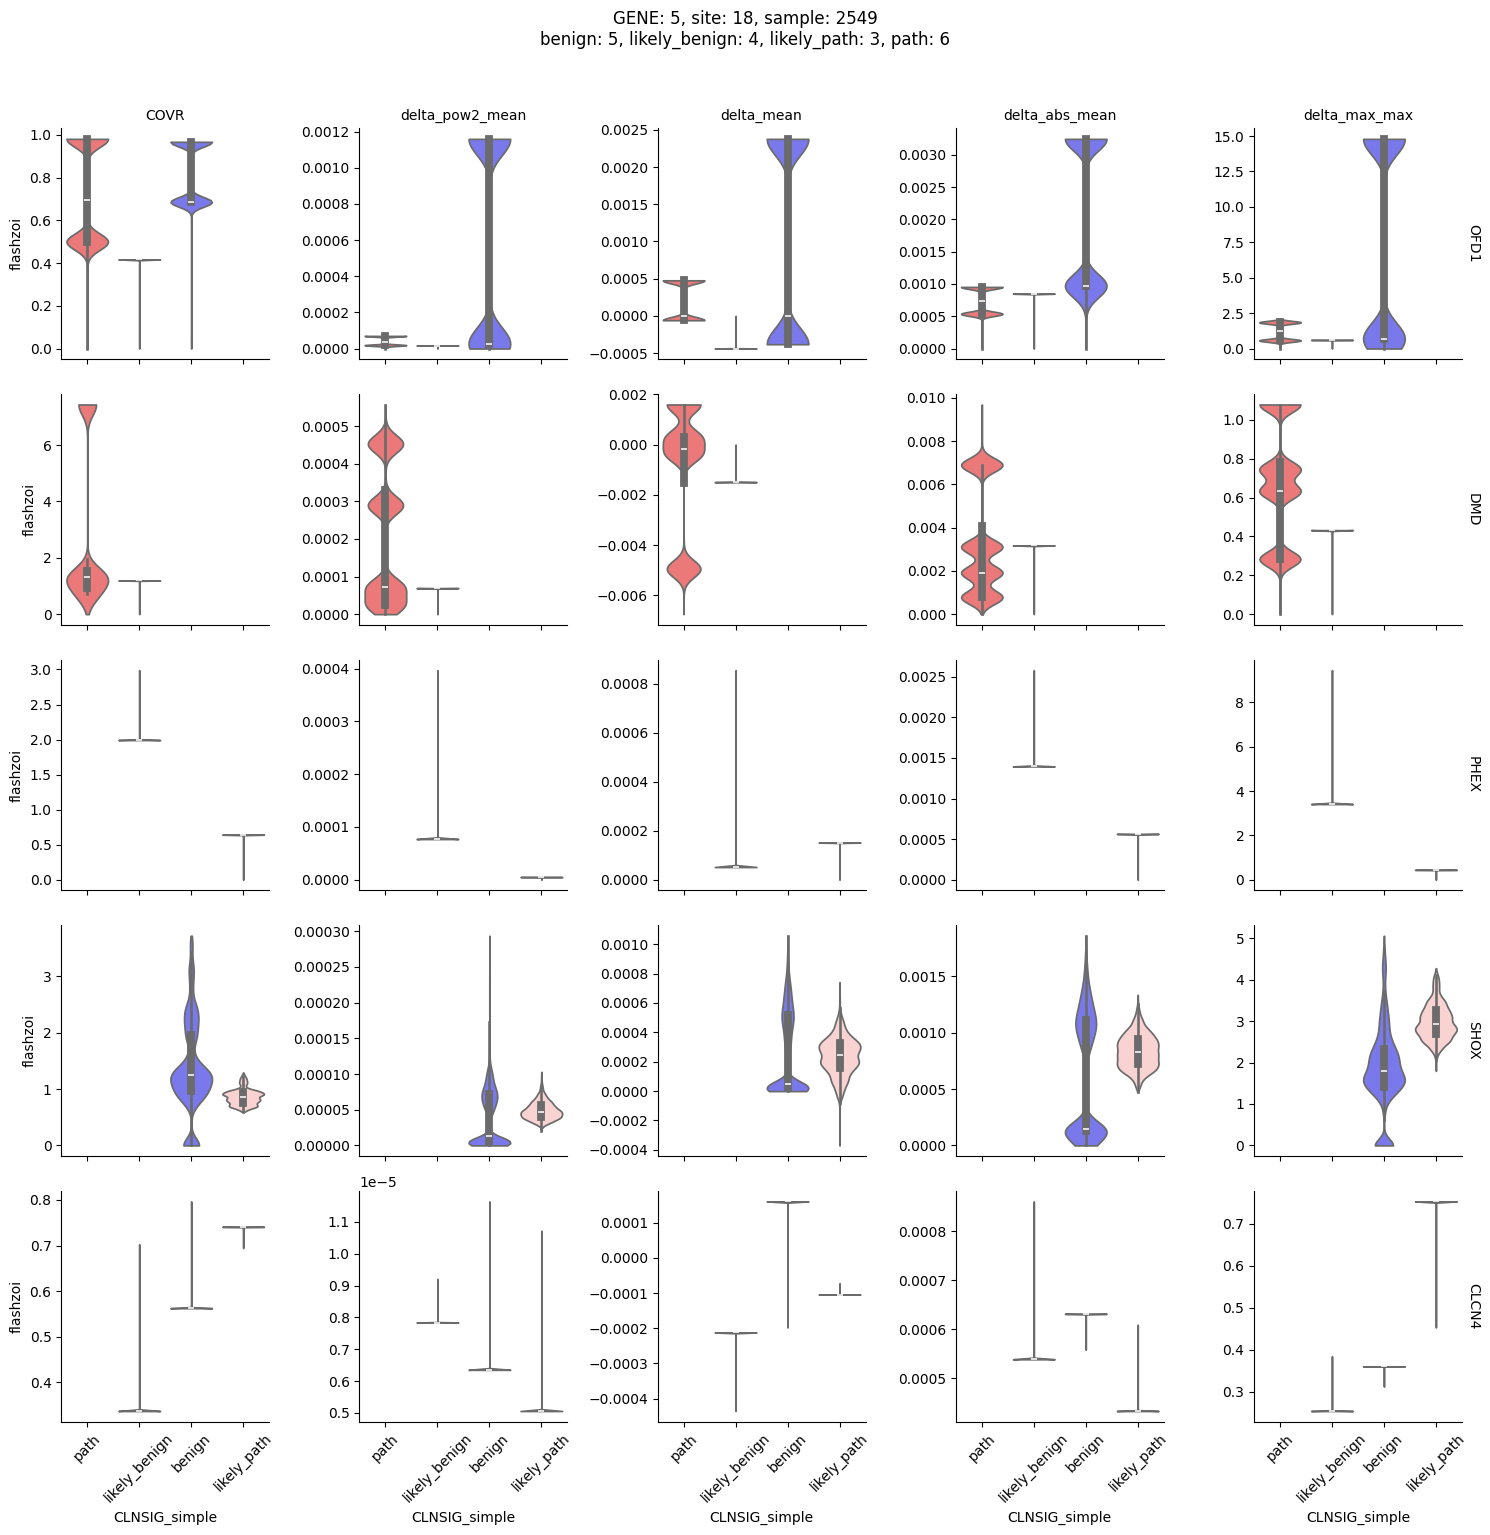

In [17]:
vep_select = delta_df.loc[delta_df["GENE"].isin(clnsig_simple_counts.index)]

g = plot_violin(vep_select, row="GENE")


## Plot individuals across all VEP scores

Since our results are split by chromosome, this approach lets up import multiple xarray Datasets into a single object

In [13]:
vep_df = vp.load_vep_results_mfdataset(xr_mfds_dir=os.path.join(
    os.path.expanduser('~'),
    "projects/data/1000_Genomes_on_GRCh38",
    variant_set,
))

/home/schilder/.conda/envs/flashzoi/lib/python3.12/site-packages/zarr/codecs/vlen_utf8.py:44: UserWarning: The codec `vlen-utf8` is currently not part in the Zarr format 3 specification. It may not be supported by other zarr implementations and may change in the future.
  return cls(**configuration_parsed)
/home/schilder/.conda/envs/flashzoi/lib/python3.12/site-packages/zarr/codecs/vlen_utf8.py:44: UserWarning: The codec `vlen-utf8` is currently not part in the Zarr format 3 specification. It may not be supported by other zarr implementations and may change in the future.
  return cls(**configuration_parsed)
/home/schilder/.conda/envs/flashzoi/lib/python3.12/site-packages/zarr/codecs/vlen_utf8.py:44: UserWarning: The codec `vlen-utf8` is currently not part in the Zarr format 3 specification. It may not be supported by other zarr implementations and may change in the future.
  return cls(**configuration_parsed)
/home/schilder/.conda/envs/flashzoi/lib/python3.12/site-packages/zarr/codecs

In [17]:
print(mfds_df.shape)
mfds_df.head()

(8360720, 12)


,site,sample,ploid,evo2_40b_base,evo2_7b,flashzoi,spliceai,dnabert2,spliceai_mm,evo2_40b,evo2_7b_base,slot
0,chr22:17085042-17085043_T_C,REF,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,COVR
1,chr22:17085042-17085043_T_C,REF,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,COVR
2,chr22:17085042-17085043_T_C,HG00096,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,COVR
3,chr22:17085042-17085043_T_C,HG00096,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,COVR
4,chr22:17085042-17085043_T_C,HG00097,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,COVR


In [18]:
mfds_df["site"].str.split(":").str[0].value_counts()

site
chrX     4465848
chr22    3894872
Name: count, dtype: int64

In [20]:
X = mfds_df.pivot(index=["site"], 
                  columns=["sample","ploid"], 
                  values="flashzoi")
X.shape

(722, 5098)

In [21]:
import umap

dr_out = umap.UMAP(n_components=2, random_state=42).fit_transform(X)

/home/schilder/.conda/envs/flashzoi/lib/python3.12/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/home/schilder/.conda/envs/flashzoi/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


In [26]:
from sklearn.decomposition import NMF

dr_out = NMF(n_components=2, 
             max_iter=5000,
             random_state=42).fit_transform(X)

In [28]:
from sklearn.decomposition import PCA

dr_out = PCA(n_components=2, random_state=42).fit_transform(X)

In [29]:
import src.onekg as og

og_meta = og.get_sample_metadata()

In [30]:
import plotly.express as px

dr_df = pd.concat(
    [pd.DataFrame({'sample': X.columns.get_level_values(0)}),
     pd.DataFrame(dr_out, columns=["dim1", "dim2"])],
     axis=1
     ).merge(og_meta, left_on="sample", right_on="Individual ID", how="left")

fig = px.scatter(dr_df, x="dim1", y="dim2", color="Super Population")
fig.show()
